In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    BatchNormalization
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import os

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:

X_train_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_train.npy"
)

X_val_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_val.npy"
)

X_test_pad = np.load(
    "/content/drive/MyDrive/processed_data/X_test.npy"
)

y_train = np.load(
    "/content/drive/MyDrive/processed_data/y_train.npy"
)

y_val = np.load(
    "/content/drive/MyDrive/processed_data/y_val.npy"
)

y_test = np.load(
    "/content/drive/MyDrive/processed_data/y_test.npy"
)

In [26]:
print("Training:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Testing:", X_test_pad.shape)

Training: (34998, 200)
Validation: (7502, 200)
Testing: (7500, 200)


In [27]:
VOCAB_SIZE = 20000

BASE_SEQUENCE_LENGTH = 200

BASE_EMBEDDING_DIM = 128

BASE_HIDDEN_UNITS = 64

BASE_DROPOUT = 0.3

BASE_BATCH_SIZE = 64

BASE_EPOCHS = 10

In [28]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    probabilities = model.predict(
        X_test,
        verbose=0
    ).flatten()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    print("\n", model_name)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [29]:
#Build Baseline BiLSTM
def build_baseline_BiLSTM():

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

         Bidirectional(
        LSTM(64)

        ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            0.3
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [30]:
#Train Baseline BiLSTM
baseline_BiLSTM = build_baseline_BiLSTM()

baseline_history = baseline_BiLSTM.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8014 - loss: 0.4213 - val_accuracy: 0.8672 - val_loss: 0.3115
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9086 - loss: 0.2440 - val_accuracy: 0.8778 - val_loss: 0.3075
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9377 - loss: 0.1730 - val_accuracy: 0.8744 - val_loss: 0.3804
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9645 - loss: 0.1053 - val_accuracy: 0.8616 - val_loss: 0.3954
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9792 - loss: 0.0646 - val_accuracy: 0.8543 - val_loss: 0.4641


In [31]:
#Evaluate Baseline BiLSTM
baseline_result = evaluate_model(

    baseline_BiLSTM,

    X_test_pad,

    y_test,

    "Baseline BiLSTM"
)


 Baseline BiLSTM
Accuracy: 0.8604
Precision: 0.853
Recall: 0.8709
F1 Score: 0.8619
ROC-AUC: 0.9317


In [32]:
os.makedirs(
    "saved_models",
    exist_ok=True
)

baseline_BiLSTM.save(
    "saved_models/baseline_BiLSTM.keras"
)

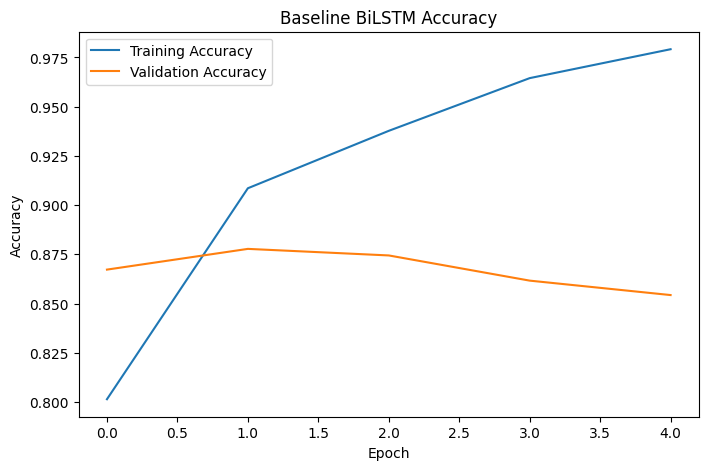

In [33]:
#Plot Baseline Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Baseline BiLSTM Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [34]:
embedding_results = []

for embedding_dim in [64, 128, 256]:

    print(
        "\nTesting Embedding Dimension:",
        embedding_dim
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=embedding_dim,
            input_length=200
        ),

         Bidirectional(
        LSTM(64)
    ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    val_accuracy = max(
        history.history["val_accuracy"]
    )

    embedding_results.append({

        "Embedding Dimension": embedding_dim,

        "Validation Accuracy": val_accuracy

    })


Testing Embedding Dimension: 64
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8051 - loss: 0.4197 - val_accuracy: 0.8652 - val_loss: 0.3194
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9056 - loss: 0.2464 - val_accuracy: 0.8720 - val_loss: 0.3128
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9329 - loss: 0.1852 - val_accuracy: 0.8692 - val_loss: 0.3221

Testing Embedding Dimension: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7895 - loss: 0.4511 - val_accuracy: 0.8591 - val_loss: 0.3825
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9011 - loss: 0.2624 - val_accuracy: 0.8608 - val_loss: 0.3366
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9350 - loss: 0.1820 - val_accuracy: 0.8640 - val_loss: 0.4125

Testing Embedding Dimension: 256
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7969 - loss: 0.4400 - val_accuracy: 0.8654 - val_loss: 0.3252
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 

In [35]:
embedding_df = pd.DataFrame(
    embedding_results
)

embedding_df

,Embedding Dimension,Validation Accuracy
0,64,0.872034
1,128,0.864036
2,256,0.865369


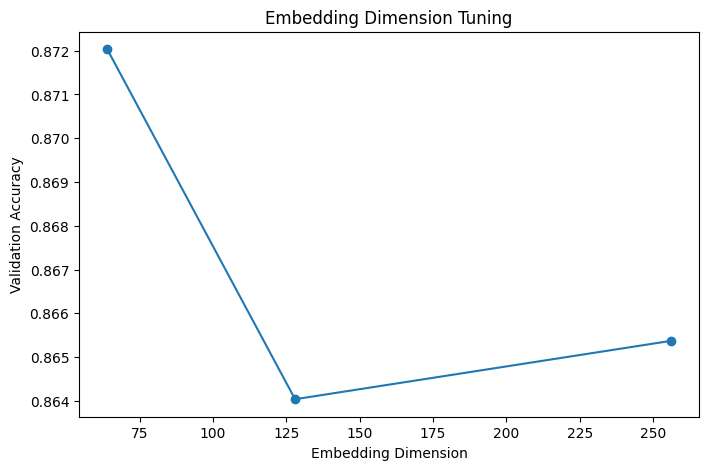

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    embedding_df["Embedding Dimension"],
    embedding_df["Validation Accuracy"],
    marker="o"
)

plt.title(
    "Embedding Dimension Tuning"
)

plt.xlabel(
    "Embedding Dimension"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.show()

In [37]:
hidden_results = []

for units in [32, 64, 128]:

    print(
        "\nTesting Hidden Units:",
        units
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),


          Bidirectional(
        LSTM(units)
    ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    hidden_results.append({

        "Hidden Units": units,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Hidden Units: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.7857 - loss: 0.4417 - val_accuracy: 0.8511 - val_loss: 0.3421
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9067 - loss: 0.2464 - val_accuracy: 0.8727 - val_loss: 0.3393
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9393 - loss: 0.1712 - val_accuracy: 0.8692 - val_loss: 0.3800

Testing Hidden Units: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7831 - loss: 0.4700 - val_accuracy: 0.8627 - val_loss: 0.3322
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8985 - loss: 0.2677 - val_accuracy: 0.8579 - val_loss: 0.3418
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9341 - loss: 0.1847 - val_accuracy: 0.8683 - val_loss: 0.3441

Testing Hidden Units: 128
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.7486 - loss: 0.5038 - val_accuracy: 0.8343 - val_loss: 0.3984
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step -

In [38]:
hidden_df = pd.DataFrame(
    hidden_results
)

hidden_df

,Hidden Units,Validation Accuracy
0,32,0.872701
1,64,0.868302
2,128,0.869102


In [39]:
#Tune Dropout
dropout_results = []

for dropout_rate in [0.2, 0.3, 0.5]:

    print(
        "\nTesting Dropout:",
        dropout_rate
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        Bidirectional(
        LSTM(64)
    ),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    dropout_results.append({

        "Dropout": dropout_rate,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Dropout: 0.2
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7950 - loss: 0.4352 - val_accuracy: 0.8404 - val_loss: 0.3854
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9036 - loss: 0.2530 - val_accuracy: 0.8754 - val_loss: 0.3271
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9328 - loss: 0.1857 - val_accuracy: 0.8704 - val_loss: 0.3701

Testing Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7876 - loss: 0.4487 - val_accuracy: 0.8628 - val_loss: 0.3455
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9046 - loss: 0.2532 - val_accuracy: 0.8499 - val_loss: 0.3600
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9361 - loss: 0.1795 - val_accuracy: 0.8548 - val_loss: 0.3646

Testing Dropout: 0.5
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8059 - loss: 0.4310 - val_accuracy: 0.8615 - val_loss: 0.3413
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy

In [40]:
#Display Dropout Results
dropout_df = pd.DataFrame(
    dropout_results
)

dropout_df

,Dropout,Validation Accuracy
0,0.2,0.875367
1,0.3,0.862837
2,0.5,0.867502


In [41]:
#Tune Recurrent Dropout
recurrent_results = []

for recurrent_dropout in [0.0, 0.2, 0.3]:

    print(
        "\nTesting Recurrent Dropout:",
        recurrent_dropout
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        Bidirectional(LSTM(
            64,
            dropout=0.3,
            recurrent_dropout=recurrent_dropout
        )),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    recurrent_results.append({

        "Recurrent Dropout":
            recurrent_dropout,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Recurrent Dropout: 0.0
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7896 - loss: 0.4464 - val_accuracy: 0.8676 - val_loss: 0.3192
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9013 - loss: 0.2611 - val_accuracy: 0.8492 - val_loss: 0.3358
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9273 - loss: 0.1943 - val_accuracy: 0.8687 - val_loss: 0.3424

Testing Recurrent Dropout: 0.2
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 725s 1s/step - accuracy: 0.7488 - loss: 0.5238 - val_accuracy: 0.8163 - val_loss: 0.4193
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 722s 1s/step - accuracy: 0.8375 - loss: 0.3913 - val_accuracy: 0.8331 - val_loss: 0.4266
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 726s 1s/step - accuracy: 0.8771 - loss: 0.3188 - val_accuracy: 0.8578 - val_loss: 0.3482

Testing Recurrent Dropout: 0.3
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 721s 1s/step - accuracy: 0.7345 - loss: 0.5421 - val_accuracy: 0.8194 - val_loss: 0.4278
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 715s 1s/

In [42]:
recurrent_df = pd.DataFrame(
    recurrent_results
)

recurrent_df

,Recurrent Dropout,Validation Accuracy
0,0.0,0.868702
1,0.2,0.857771
2,0.3,0.856972


In [43]:
#Try Batch Normalization
batchnorm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    Bidirectional(LSTM(
        64,
        dropout=0.3
    )),

    BatchNormalization(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
batchnorm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [45]:
batchnorm_history = batchnorm_model.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=5,

    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8039 - loss: 0.4159 - val_accuracy: 0.8720 - val_loss: 0.3060
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.8990 - loss: 0.2563 - val_accuracy: 0.8336 - val_loss: 0.3919
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9251 - loss: 0.1936 - val_accuracy: 0.8683 - val_loss: 0.4593
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9486 - loss: 0.1415 - val_accuracy: 0.8528 - val_loss: 0.4703
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9630 - loss: 0.1038 - val_accuracy: 0.8475 - val_loss: 0.4865


In [46]:
learning_rate_results = []

for lr in [0.001, 0.0005, 0.0001]:

    print(
        "\nTesting Learning Rate:",
        lr
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        Bidirectional(LSTM(
            64,
            dropout=0.3
        )),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(
        learning_rate=lr
    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    learning_rate_results.append({

        "Learning Rate": lr,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Learning Rate: 0.001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7868 - loss: 0.4543 - val_accuracy: 0.8487 - val_loss: 0.3521
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9005 - loss: 0.2643 - val_accuracy: 0.8728 - val_loss: 0.3201
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9312 - loss: 0.1926 - val_accuracy: 0.8724 - val_loss: 0.3278

Testing Learning Rate: 0.0005
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7847 - loss: 0.4469 - val_accuracy: 0.8594 - val_loss: 0.3364
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9029 - loss: 0.2568 - val_accuracy: 0.8735 - val_loss: 0.3013
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9290 - loss: 0.1979 - val_accuracy: 0.8732 - val_loss: 0.3588

Testing Learning Rate: 0.0001
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6316 - loss: 0.6200 - val_accuracy: 0.8262 - val_loss: 0.4030
Epoch

In [47]:
learning_rate_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_df

,Learning Rate,Validation Accuracy
0,0.0010,0.872834
1,0.0005,0.873500
2,0.0001,0.874567


In [48]:
optimizer_results = []

optimizers = {

    "Adam": Adam(
        learning_rate=0.0005
    ),

    "RMSprop": RMSprop(
        learning_rate=0.0005
    )
}


for optimizer_name, optimizer in optimizers.items():

    print(
        "\nTesting Optimizer:",
        optimizer_name
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        Bidirectional(LSTM(
            64,
            dropout=0.3
        )),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=64,

        verbose=1
    )

    optimizer_results.append({

        "Optimizer": optimizer_name,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Optimizer: Adam
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7754 - loss: 0.4509 - val_accuracy: 0.8596 - val_loss: 0.3391
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9031 - loss: 0.2557 - val_accuracy: 0.8744 - val_loss: 0.3091
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9282 - loss: 0.1953 - val_accuracy: 0.8762 - val_loss: 0.3099

Testing Optimizer: RMSprop
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6734 - loss: 0.5773 - val_accuracy: 0.8427 - val_loss: 0.3687
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8495 - loss: 0.3633 - val_accuracy: 0.8575 - val_loss: 0.3279
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8815 - loss: 0.3016 - val_accuracy: 0.8687 - val_loss: 0.3305


In [49]:
optimizer_df = pd.DataFrame(
    optimizer_results
)

optimizer_df

,Optimizer,Validation Accuracy
0,Adam,0.876166
1,RMSprop,0.868702


In [50]:
batch_results = []

for batch_size in [32, 64, 128]:

    print(
        "\nTesting Batch Size:",
        batch_size
    )

    model = Sequential([

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=200
        ),

        Bidirectional(LSTM(
            64,
            dropout=0.3
        )),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.0005
        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]
    )

    history = model.fit(

        X_train_pad,

        y_train,

        validation_data=(
            X_val_pad,
            y_val
        ),

        epochs=3,

        batch_size=batch_size,

        verbose=1
    )

    batch_results.append({

        "Batch Size": batch_size,

        "Validation Accuracy":
            max(
                history.history[
                    "val_accuracy"
                ]
            )

    })


Testing Batch Size: 32
Epoch 1/3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7979 - loss: 0.4332 - val_accuracy: 0.8670 - val_loss: 0.3356
Epoch 2/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9021 - loss: 0.2588 - val_accuracy: 0.8635 - val_loss: 0.3302
Epoch 3/3
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9282 - loss: 0.1995 - val_accuracy: 0.8692 - val_loss: 0.3247

Testing Batch Size: 64
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7845 - loss: 0.4412 - val_accuracy: 0.8674 - val_loss: 0.3278
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9027 - loss: 0.2559 - val_accuracy: 0.8666 - val_loss: 0.3287
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9296 - loss: 0.1939 - val_accuracy: 0.8563 - val_loss: 0.3705

Testing Batch Size: 128
Epoch 1/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7150 - loss: 0.5282 - val_accuracy: 0.8510 - val_loss: 0.3515
Epoch 2/3
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step 

In [51]:
batch_df = pd.DataFrame(
    batch_results
)

batch_df

,Batch Size,Validation Accuracy
0,32,0.869235
1,64,0.867369
2,128,0.877766


In [52]:
optimized_BiLSTM = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=200
    ),

    Bidirectional(LSTM(
        64,
        dropout=0.3,
        recurrent_dropout=0.2
    )),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [53]:
optimized_optimizer = Adam(
    learning_rate=0.0005
)


optimized_BiLSTM.compile(

    optimizer=optimized_optimizer,

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


optimized_BiLSTM.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_32                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True
)

In [55]:
learning_rate_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=1,

    min_lr=0.00001
)

In [ ]:
optimized_history = optimized_BiLSTM.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stopping,
        learning_rate_scheduler
    ]
)


Epoch 1/10
124/547 ━━━━━━━━━━━━━━━━━━━━ 8:53 1s/step - accuracy: 0.8448 - loss: 0.3910

In [ ]:
optimized_BiLSTM.save(
    "saved_models/optimized_BiLSTM.keras"
)

print(
    "Optimized BiLSTM saved successfully!"
)

In [ ]:
optimized_result = evaluate_model(

    optimized_BiLSTM,

    X_test_pad,

    y_test,

    "Optimized BiLSTM"
)

In [ ]:
comparison = pd.DataFrame([

    baseline_result,

    optimized_result

])

comparison = comparison.round(4)

comparison

In [ ]:
accuracy_improvement = (

    optimized_result["Accuracy"]

    -

    baseline_result["Accuracy"]
)

f1_improvement = (

    optimized_result["F1 Score"]

    -

    baseline_result["F1 Score"]
)

roc_auc_improvement = (

    optimized_result["ROC-AUC"]

    -

    baseline_result["ROC-AUC"]
)


print(
    "Accuracy Improvement:",
    round(
        accuracy_improvement,
        4
    )
)

print(
    "F1 Score Improvement:",
    round(
        f1_improvement,
        4
    )
)

print(
    "ROC-AUC Improvement:",
    round(
        roc_auc_improvement,
        4
    )
)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "accuracy"
    ],

    label="Training Accuracy"
)

plt.plot(

    optimized_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)

plt.title(
    "Optimized BiLSTM Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(

    optimized_history.history[
        "loss"
    ],

    label="Training Loss"
)

plt.plot(

    optimized_history.history[
        "val_loss"
    ],

    label="Validation Loss"
)

plt.title(
    "Optimized BiLSTM Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.show()

In [ ]:
embedding_df.to_csv(
    "saved_models/embedding_tuning.csv",
    index=False
)

hidden_df.to_csv(
    "saved_models/hidden_units_tuning.csv",
    index=False
)

dropout_df.to_csv(
    "saved_models/dropout_tuning.csv",
    index=False
)

recurrent_df.to_csv(
    "saved_models/recurrent_dropout_tuning.csv",
    index=False
)

learning_rate_df.to_csv(
    "saved_models/learning_rate_tuning.csv",
    index=False
)

optimizer_df.to_csv(
    "saved_models/optimizer_tuning.csv",
    index=False
)

batch_df.to_csv(
    "saved_models/batch_size_tuning.csv",
    index=False
)

comparison.to_csv(
    "saved_models/baseline_vs_optimized.csv",
    index=False
)

In [ ]:
print("=" * 60)

print("PHASE 5 - MODEL IMPROVEMENT COMPLETED")

print("=" * 60)

print("\nBaseline BiLSTM Accuracy:")

print(
    round(
        baseline_result["Accuracy"],
        4
    )
)

print("\nOptimized BiLSTM Accuracy:")

print(
    round(
        optimized_result["Accuracy"],
        4
    )
)

print("\nAccuracy Improvement:")

print(
    round(
        accuracy_improvement,
        4
    )
)

print("\nBaseline F1 Score:")

print(
    round(
        baseline_result["F1 Score"],
        4
    )
)

print("\nOptimized F1 Score:")

print(
    round(
        optimized_result["F1 Score"],
        4
    )
)

print("\nF1 Improvement:")

print(
    round(
        f1_improvement,
        4
    )
)

print("\nOptimized Model Saved At:")

print(
    "saved_models/optimized_BiLSTM.keras"
)